<a href="https://colab.research.google.com/github/leticiasdrummond/Artigo-renov-veis-bess-eletroposto/blob/main/Configura%C3%A7%C3%A3o_estilo_IEEE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Com base nos arquivos de código (`.ipynb`) enviados, pude identificar as variáveis e os gráficos que você estava gerando. Os gráficos originais focavam em visualizar o consumo da rede, a carga/descarga da bateria (SoC) e o resumo de energia (em formato de barras).

Para publicações em conferências e revistas do **IEEE**, os gráficos gerados de forma padrão pelo `matplotlib` (que você usou no arquivo) precisam de ajustes para garantir legibilidade técnica, tamanho físico adequado à diagramação e contraste, seja em telas ou em papel preto e branco.

Abaixo, apresento o layout e estilo propostos, seguidos do código ajustado pronto para rodar no Google Colab.

### 1. Padrão Proposto para Publicações IEEE

* **Tamanhos (Dimensões da Figura):** Os artigos do IEEE possuem formato de duas colunas. Figuras de **1 coluna** devem ter no máximo **3.5 polegadas** (aprox. 8.9 cm) de largura. Figuras de **2 colunas** (para detalhes extensos no eixo X) devem ter cerca de **7.16 polegadas** de largura. A altura geralmente varia entre 2.5 e 3 polegadas.
* **Fontes:** O padrão IEEE exige fontes serifadas (*Times New Roman*) com tamanhos entre **8pt e 10pt**. Rótulos de eixos devem ser claros e fáceis de ler sem sobreposição.
* **Cores e Contraste:** É recomendável o uso de padrões de linha diferentes (sólidas, tracejadas, pontilhadas) e marcadores para que as informações continuem distinguíveis se o artigo for impresso em escala de cinza.
* **Qualidade e Exportação:** A resolução mínima deve ser de **300 DPI**. O formato ideal para incorporar em documentos LaTeX ou Word gerando PDF final é o **`.pdf`** ou `.eps` (gráficos vetoriais), evitando granulação comum do `.png`.
* **Títulos de Gráficos:** No padrão IEEE, o título interno na área do gráfico (`plt.title()`) **não deve ser usado**. As figuras são descritas na legenda textual ("*Caption*") logo abaixo da imagem no corpo do documento final.

---

### 2. Código Completo para o Google Colab

Este script já contém todos os hiperparâmetros de configuração de design (RCParams do `matplotlib`). Para rodar sem erros, incluí a criação de um DataFrame de *mock* (dados simulados idênticos à estrutura das suas variáveis `df` e `summary_df` ). Basta copiar e colar em uma célula do Colab:

/tmp/ipykernel_1709/25067084.py:47: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  horas = pd.date_range("2025-02-01 00:00", "2025-02-01 23:59", freq="H")


Gerando gráficos no Padrão IEEE...



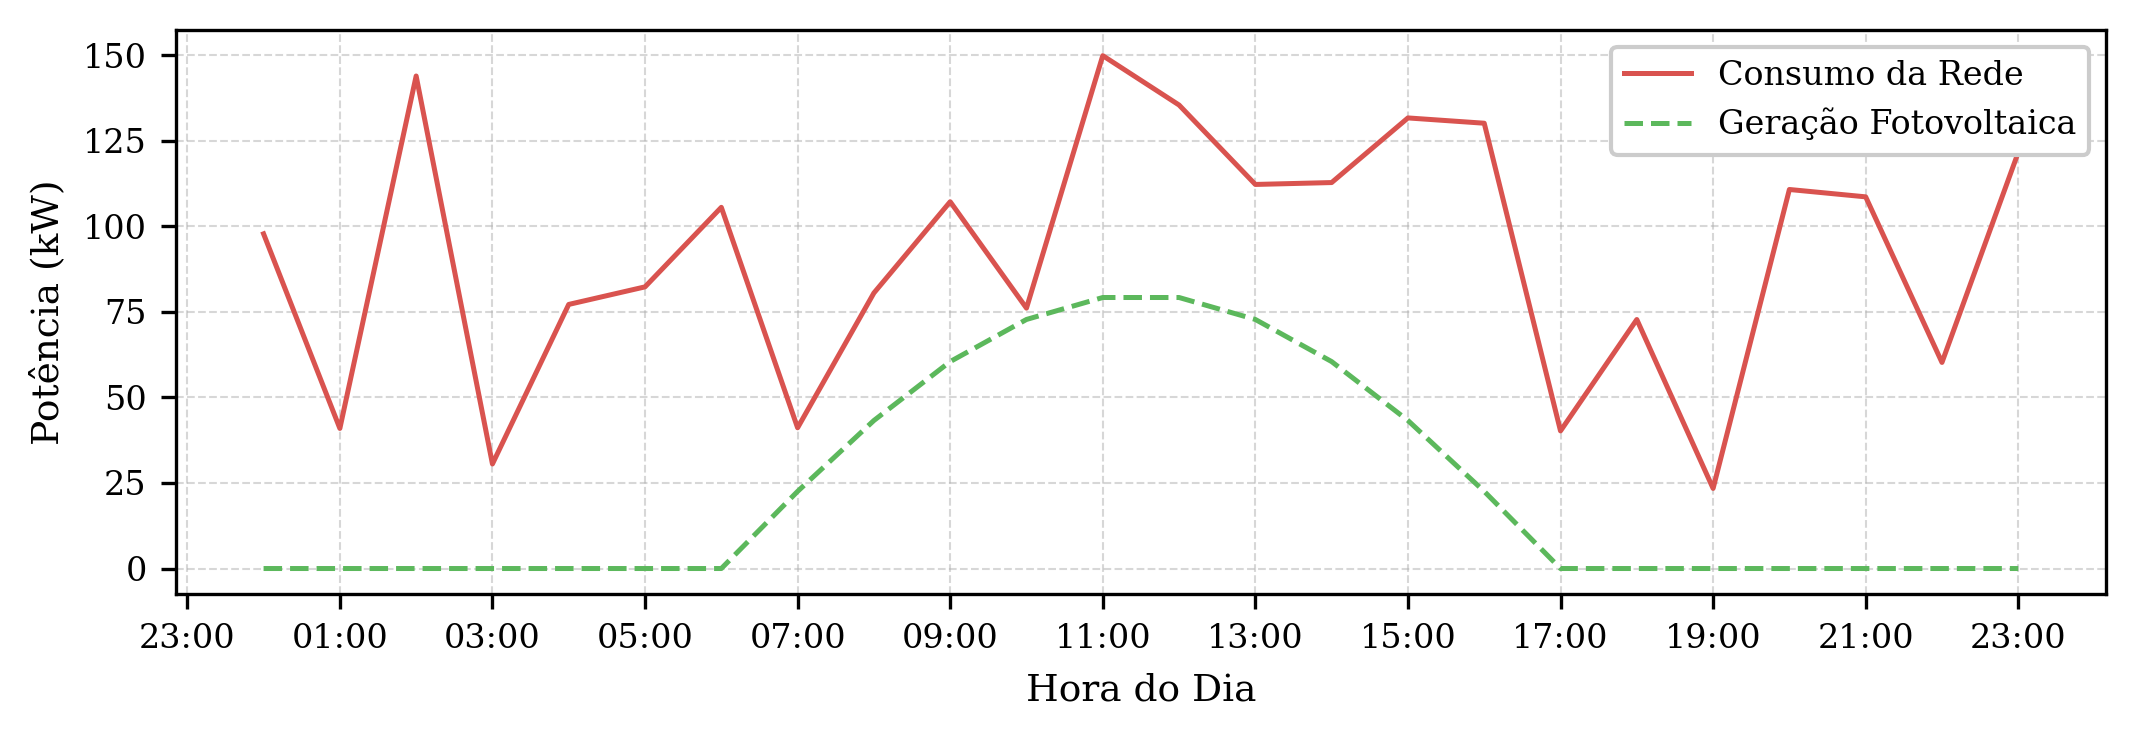

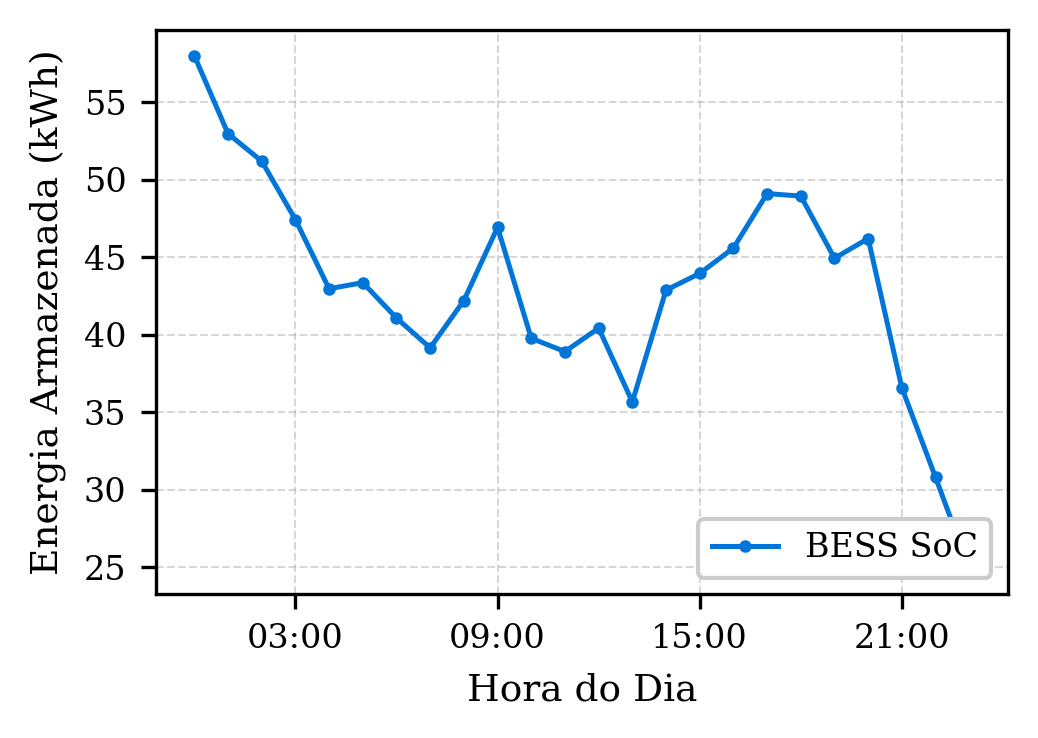

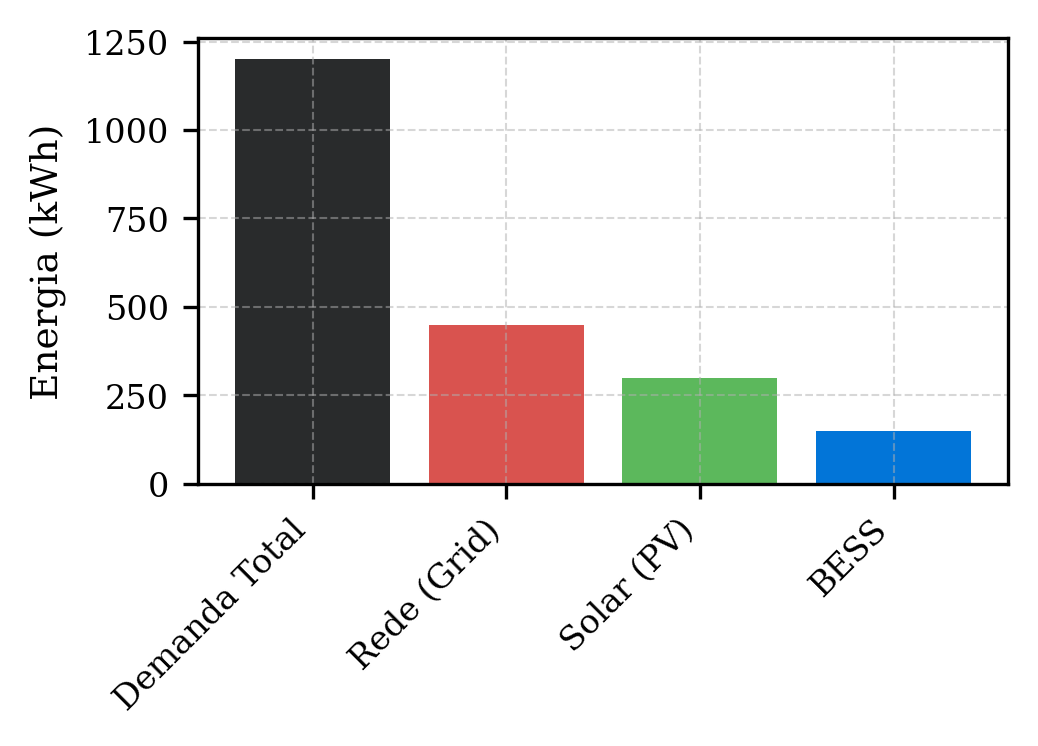


Sucesso! As figuras foram formatadas para PDF (vetor) e estão salvas na pasta: 'figuras_ieee'


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates

# ==========================================
# 1. CONFIGURAÇÃO DE ESTILO - PADRÃO IEEE
# ==========================================
def setup_ieee_style():
    """Configura o matplotlib globalmente para o padrão de publicação IEEE."""
    # Uso de fonte Serif para alinhar ao Times New Roman do LaTeX/Word
    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']

    # Tamanhos de fonte padronizados (entre 8 e 10pt)
    mpl.rcParams['font.size'] = 8         # Fonte base
    mpl.rcParams['axes.labelsize'] = 9    # Rótulos dos eixos (X e Y)
    mpl.rcParams['xtick.labelsize'] = 8   # Ticks eixo X
    mpl.rcParams['ytick.labelsize'] = 8   # Ticks eixo Y
    mpl.rcParams['legend.fontsize'] = 8   # Fonte da legenda

    # Linhas e eixos mais polidos
    mpl.rcParams['axes.linewidth'] = 0.8
    mpl.rcParams['lines.linewidth'] = 1.2

    # Grid discreto
    mpl.rcParams['axes.grid'] = True
    mpl.rcParams['grid.alpha'] = 0.5
    mpl.rcParams['grid.linestyle'] = '--'
    mpl.rcParams['grid.linewidth'] = 0.5

    # Exportação em Alta Qualidade Vetorial
    mpl.rcParams['figure.dpi'] = 300
    mpl.rcParams['savefig.dpi'] = 300
    mpl.rcParams['savefig.bbox'] = 'tight' # Remove bordas brancas sobressalentes
    mpl.rcParams['savefig.format'] = 'pdf' # Ideal para artigo científico

# Executa as configurações globais
setup_ieee_style()

# ==========================================
# 2. DADOS DE EXEMPLO (SUBSTITUA PELOS SEUS)
# ==========================================
# Criando dados fictícios na mesma estrutura do seu código
horas = pd.date_range("2025-02-01 00:00", "2025-02-01 23:59", freq="H")
df = pd.DataFrame(index=horas)
# Variáveis que identificamos no seu arquivo:
df["grid_draw"] = np.random.uniform(20, 150, size=len(horas))
df["pv_generation"] = np.concatenate([np.zeros(6), np.sin(np.linspace(0, np.pi, 12))*80, np.zeros(6)])
df["soc_kwh"] = 50 + np.cumsum(np.random.normal(0, 5, size=len(horas)))
df["soc_kwh"] = np.clip(df["soc_kwh"], 10, 100) # SoC entre 10% e 100%

summary_df = pd.DataFrame({
    "kWh": [1200, 450, 300, 150]
}, index=["Demanda Total", "Rede (Grid)", "Solar (PV)", "BESS"])

# Diretório para salvar as imagens corrigidas
OUT_DIR = "figuras_ieee"
os.makedirs(OUT_DIR, exist_ok=True)

# ==========================================
# 3. GERAÇÃO E EXPORTAÇÃO DOS GRÁFICOS
# ==========================================

print("Gerando gráficos no Padrão IEEE...\n")

# -- GRÁFICO 1: Potência da Rede e PV (Largura de 2 colunas para melhor resolução temporal)
fig1, ax1 = plt.subplots(figsize=(7.16, 2.5)) # 7.16 polegadas de largura
ax1.plot(df.index, df["grid_draw"], label="Consumo da Rede", color='#d9534f', linestyle='-')
ax1.plot(df.index, df["pv_generation"], label="Geração Fotovoltaica", color='#5cb85c', linestyle='--')
ax1.set_xlabel("Hora do Dia")
ax1.set_ylabel("Potência (kW)")
# ax1.set_title(...) <- Removido: O IEEE pede que o título fique apenas no Caption do artigo
ax1.legend(loc='upper right', framealpha=1.0)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.tight_layout()
fig1.savefig(os.path.join(OUT_DIR, "opt_grid_draw_with_pv_ieee.pdf"))
plt.show()

# -- GRÁFICO 2: BESS SoC (Largura de 1 coluna)
fig2, ax2 = plt.subplots(figsize=(3.5, 2.5)) # 3.5 polegadas de largura
ax2.plot(df.index, df["soc_kwh"], label="BESS SoC", color='#0275d8', linestyle='-', marker='o', markersize=2)
ax2.set_xlabel("Hora do Dia")
ax2.set_ylabel("Energia Armazenada (kWh)")
ax2.legend(loc='lower right', framealpha=1.0)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=6))
plt.tight_layout()
fig2.savefig(os.path.join(OUT_DIR, "opt_soc_with_pv_ieee.pdf"))
plt.show()

# -- GRÁFICO 3: Resumo Energético (Gráfico de Barras - 1 coluna)
fig3, ax3 = plt.subplots(figsize=(3.5, 2.5))
barras = ax3.bar(summary_df.index.astype(str), summary_df["kWh"], color=['#292b2c', '#d9534f', '#5cb85c', '#0275d8'])
ax3.set_ylabel("Energia (kWh)")
# Gira a fonte do eixo X em 45º para não colidir
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()
fig3.savefig(os.path.join(OUT_DIR, "opt_summary_with_pv_ieee.pdf"))
plt.show()

print(f"\nSucesso! As figuras foram formatadas para PDF (vetor) e estão salvas na pasta: '{OUT_DIR}'")

### O que mudou do seu script inicial para este:

1. **Remoção de Títulos (`plt.title`)**: Como discutido, o IEEE dita que imagens não devem ter títulos; tudo é descrito no "*Caption*".
2.
**`figsize` em Polegadas Exatas**: Em vez de passar `(12,3)` ou `(8,4)`  que exigiriam redimensionamento e borrariam as letras na diagramação final, agora a figura já nasce com o tamanho exato da página de publicação (3.5 e 7.16 polegadas).


3. **Formatação de Data/Hora Eixo X**: Inclusão de `mdates.DateFormatter` para transformar os eixos X, que saíam com visualização confusa ou sobreposta, em horários bem divididos.
4. **Formato Vetorial de Alta Qualidade**: Todos estão sendo exportados nativamente para `.pdf` por meio do *rcParams* para permitir a inclusão limpa nos *softwares* acadêmicos sem qualquer perda de qualidade quando dado o "zoom".